In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report)

In [16]:
data = {
    "Word_Frequency": [20, 80, 15, 90, 45, 70, 10, 85, 30, 60],
    "Link_Count": [1, 10, 0, 15, 3, 8, 1, 12, 2, 7],
    "Capital_Ratio": [0.1, 0.8, 0.05, 0.9, 0.2, 0.7, 0.1, 0.85, 0.15, 0.6],
    "Exclamation_Count": [0, 8, 1, 12, 2, 7, 0, 10, 1, 6],
    "Email_Length": [200, 700, 150, 900, 300, 650, 180, 850, 250, 600],
    "Attachment_Count": [0, 3, 0, 4, 1, 2, 0, 4, 1, 2],
    "Unknown_Sender": [0, 1, 0, 1, 0, 1, 0, 1, 0, 1],
    "Email_Type": [
        "Not Spam", "Spam", "Not Spam", "Spam", "Not Spam",
        "Spam", "Not Spam", "Spam", "Not Spam", "Spam"]}

df = pd.DataFrame(data)

In [17]:
df.head()

,Word_Frequency,Link_Count,Capital_Ratio,Exclamation_Count,Email_Length,Attachment_Count,Unknown_Sender,Email_Type
0,20,1,0.10,0,200,0,0,Not Spam
1,80,10,0.80,8,700,3,1,Spam
2,15,0,0.05,1,150,0,0,Not Spam
3,90,15,0.90,12,900,4,1,Spam
4,45,3,0.20,2,300,1,0,Not Spam


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Word_Frequency     10 non-null     int64  
 1   Link_Count         10 non-null     int64  
 2   Capital_Ratio      10 non-null     float64
 3   Exclamation_Count  10 non-null     int64  
 4   Email_Length       10 non-null     int64  
 5   Attachment_Count   10 non-null     int64  
 6   Unknown_Sender     10 non-null     int64  
 7   Email_Type         10 non-null     object 
dtypes: float64(1), int64(6), object(1)
memory usage: 772.0+ bytes


In [19]:
df.shape

(10, 8)

In [20]:
df.isnull().sum()

Word_Frequency       0
Link_Count           0
Capital_Ratio        0
Exclamation_Count    0
Email_Length         0
Attachment_Count     0
Unknown_Sender       0
Email_Type           0
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(0)

# X and y

In [23]:
X=df.drop("Email_Type",axis=1)
y=df["Email_Type"]

In [25]:
y = df["Email_Type"].map({
    "Not Spam": 0,
    "Spam": 1})
print(y.head())

0    0
1    1
2    0
3    1
4    0
Name: Email_Type, dtype: int64


# 3. Train Test Split

In [26]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.2,random_state=42)

In [28]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42)
model.fit(X_train,y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

# Prediction

In [30]:
y_pred=model.predict(X_test)

#  Accuracy

In [32]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 1.0


In [33]:
print("Accuracy %:", accuracy * 100)

Accuracy %: 100.0


# Confusion Matrix

In [35]:
cm=confusion_matrix(y_test,y_pred)
print("Confusion Matrix:",cm)

Confusion Matrix: [[4 0]
 [0 4]]


# Classification Report

In [36]:
cr=classification_report(y_test,y_pred)
print("Classification Report:",cr)

Classification Report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



# Decision Tree Visualization

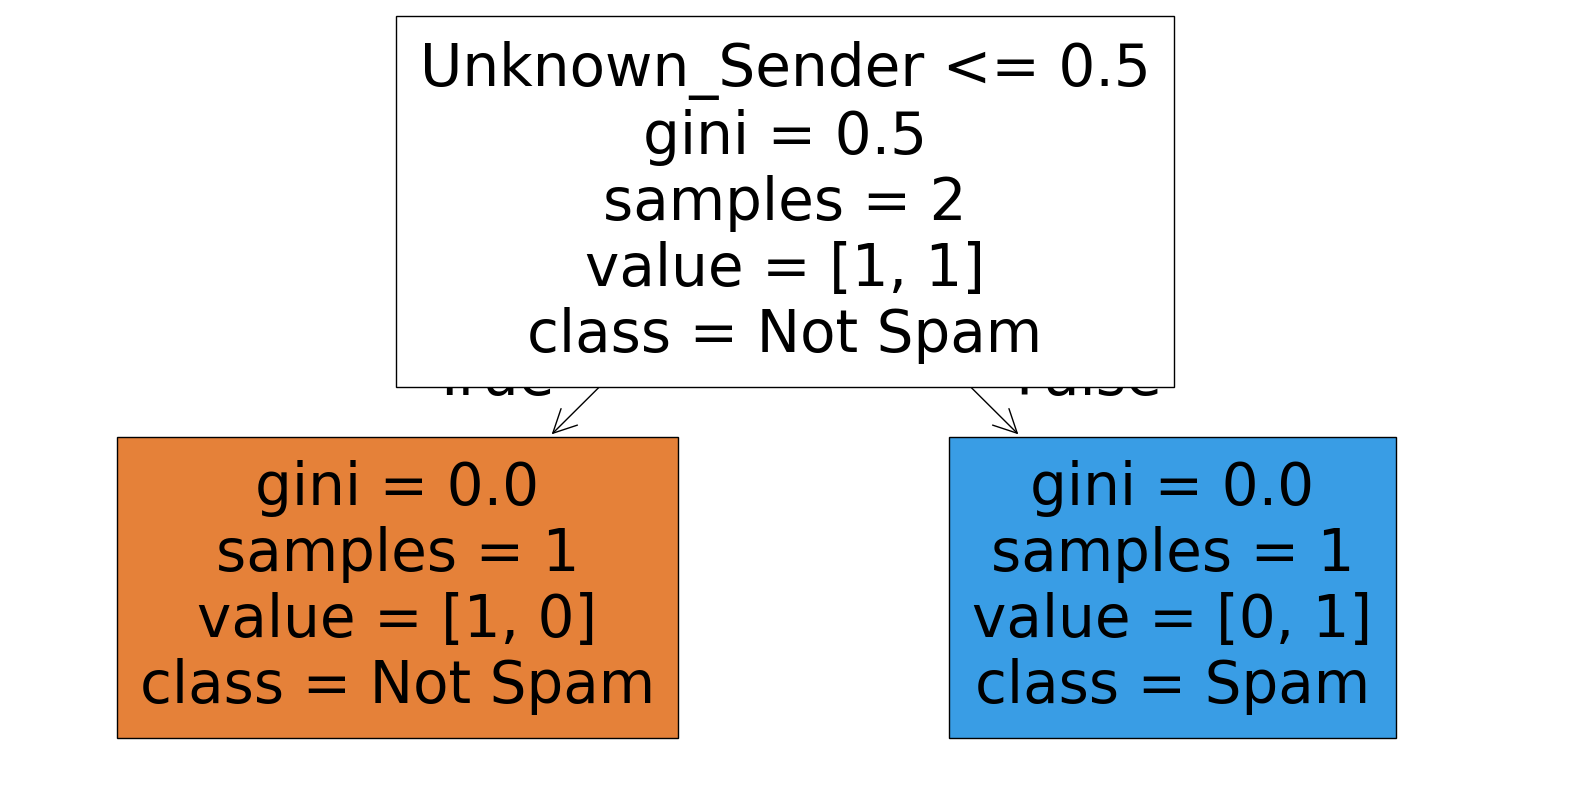

In [37]:
plt.figure(figsize=(20, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Not Spam", "Spam"],
    filled=True)
plt.show()